<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°05





**Objetivo**: Explorar y visualizar datos de Netflix usando **matplotlib** y **seaborn/plotly**, aprendiendo a elegir gráficos adecuados para distintos tipos de variables y preguntas de análisis.



**Dataset**:

Trabajaremos con el archivo `netflix_titles.csv`, que contiene información sobre los títulos disponibles en la plataforma Netflix hasta el año 2021.

| Variable       | Clase     | Descripción                                                                 |
|----------------|-----------|------------------------------------------------------------------------------|
| show_id        | caracter  | Identificador único del título en el catálogo de Netflix.                   |
| type           | caracter  | Tipo de contenido: 'Movie' o 'TV Show'.                                     |
| title          | caracter  | Título del contenido.                                                       |
| director       | caracter  | Nombre del director (puede ser nulo).                                       |
| cast           | caracter  | Lista de actores principales (puede ser nulo).                              |
| country        | caracter  | País o países donde se produjo el contenido.                                |
| date_added     | fecha     | Fecha en la que el título fue agregado al catálogo de Netflix.              |
| release_year   | entero    | Año de lanzamiento original del título.                                     |
| rating         | caracter  | Clasificación por edad (por ejemplo: 'PG-13', 'TV-MA').                      |
| duration       | caracter  | Duración del contenido (minutos o número de temporadas para series).        |
| listed_in      | caracter  | Categorías o géneros en los que está clasificado el contenido.              |
| description    | caracter  | Breve sinopsis del contenido.                                               |




In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Parte 1: Exploración visual básica

1. **Distribución de tipos de contenido**

   * Realiza un gráfico de barras mostrando la cantidad de películas vs series (`type`).
   * Pregunta guía: ¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?

2. **Histograma de años de lanzamiento**

   * Muestra cómo se distribuyen los títulos según su `release_year`.
   * Pregunta guía: ¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?

3. **Proporción de clasificaciones por edad (`rating`)**

   * Haz un gráfico circular o de barras.
   * Pregunta guía: ¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?



Dimensiones del dataset:
(8807, 12)

Columnas disponibles:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Valores nulos por columna:


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


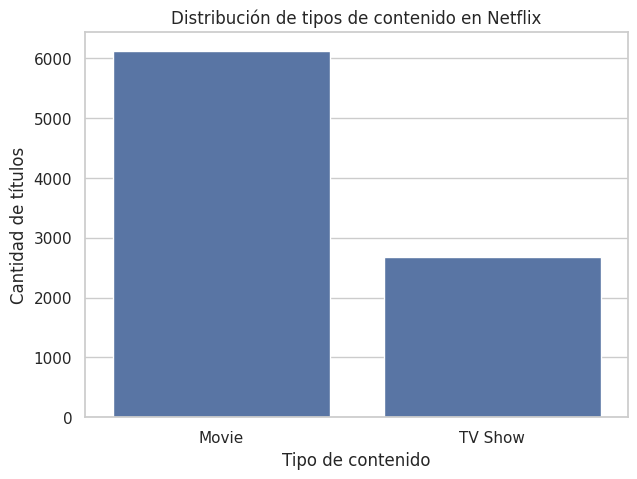

Cantidad por tipo de contenido:


,count
type,
Movie,6131
TV Show,2676


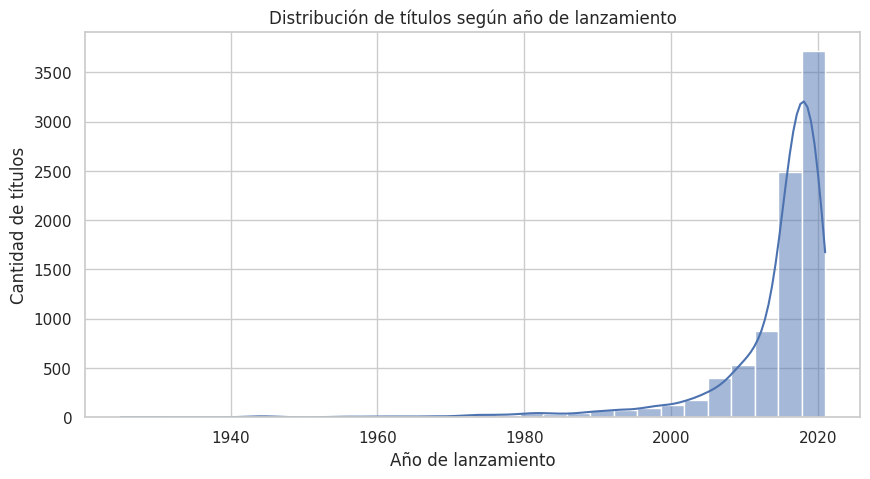

Resumen de años de lanzamiento:


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


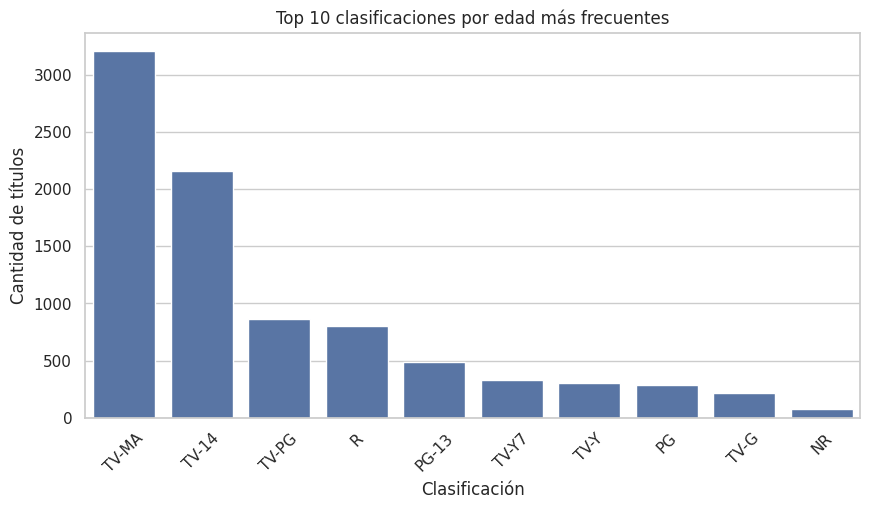

Top 10 clasificaciones por edad:


,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [6]:
# Parte 1: Exploración visual básica

import numpy as np

# Revisar información general del dataset
print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nValores nulos por columna:")
display(df.isnull().sum())

# 1. Distribución de tipos de contenido
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Distribución de tipos de contenido en Netflix")
plt.xlabel("Tipo de contenido")
plt.ylabel("Cantidad de títulos")
plt.show()

print("Cantidad por tipo de contenido:")
display(df["type"].value_counts())

# 2. Histograma de años de lanzamiento
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="release_year", bins=30, kde=True)
plt.title("Distribución de títulos según año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Cantidad de títulos")
plt.show()

print("Resumen de años de lanzamiento:")
display(df["release_year"].describe())

# 3. Proporción de clasificaciones por edad
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title("Top 10 clasificaciones por edad más frecuentes")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad de títulos")
plt.xticks(rotation=45)
plt.show()

print("Top 10 clasificaciones por edad:")
display(rating_counts)

El dataset de Netflix contiene **8807 títulos** y **12 columnas**. Las variables principales permiten analizar el tipo de contenido, título, país, fecha de incorporación, año de lanzamiento, clasificación etaria, duración, género y descripción. También se observan valores faltantes en algunas columnas, especialmente en `director` con 2634 nulos, `cast` con 825 nulos y `country` con 831 nulos. Esto es esperable en bases de contenido audiovisual, ya que no todos los títulos tienen información completa de elenco, dirección o país de origen.

En la distribución por tipo de contenido, se observa que predominan claramente las **películas**, con **6131 registros**, frente a **2676 series**. Esto indica que el catálogo analizado de Netflix está más orientado a películas que a series, al menos en cantidad de títulos. Para los usuarios, esto implica una mayor disponibilidad de contenido individual o de corta duración en comparación con producciones seriadas.

El histograma de años de lanzamiento muestra que la mayoría de los títulos son relativamente recientes. La mediana del año de lanzamiento es **2017**, el promedio es aproximadamente **2014**, y el 75% de los títulos fue lanzado antes o durante **2019**. Esto sugiere que Netflix concentra gran parte de su catálogo en contenido moderno, especialmente producido desde la década de 2010 en adelante, aunque también conserva títulos antiguos desde 1925.

Respecto a las clasificaciones por edad, la más frecuente es **TV-MA**, con **3207 títulos**, seguida por **TV-14**, con **2160 títulos**. Esto muestra que una parte importante del catálogo está orientada a público adulto y adolescente. En menor medida aparecen clasificaciones familiares o infantiles como TV-Y7, TV-Y, PG y TV-G, por lo que el catálogo tiene diversidad, pero con predominio de contenido para audiencias maduras.



## 🎨 Parte 2: Tendencias y evolución en el tiempo

4. **Número de títulos agregados por año**

   * Usa `date_added` (convertido a fecha) y grafica una serie temporal.
   * Pregunta guía: ¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?

5. **Heatmap de lanzamientos por año y mes**

   * Construye un mapa de calor con `year_added` y `month_added`.
   * Pregunta guía: ¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?

6. **Duración de películas por género**

   * Extrae la duración en minutos y crea un boxplot agrupado por género principal.
   * Pregunta guía: ¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?


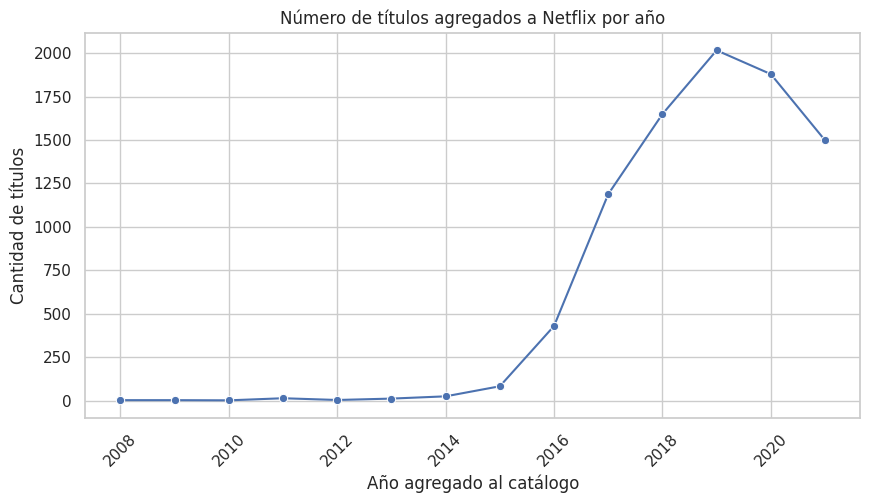

Títulos agregados por año:


,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,429


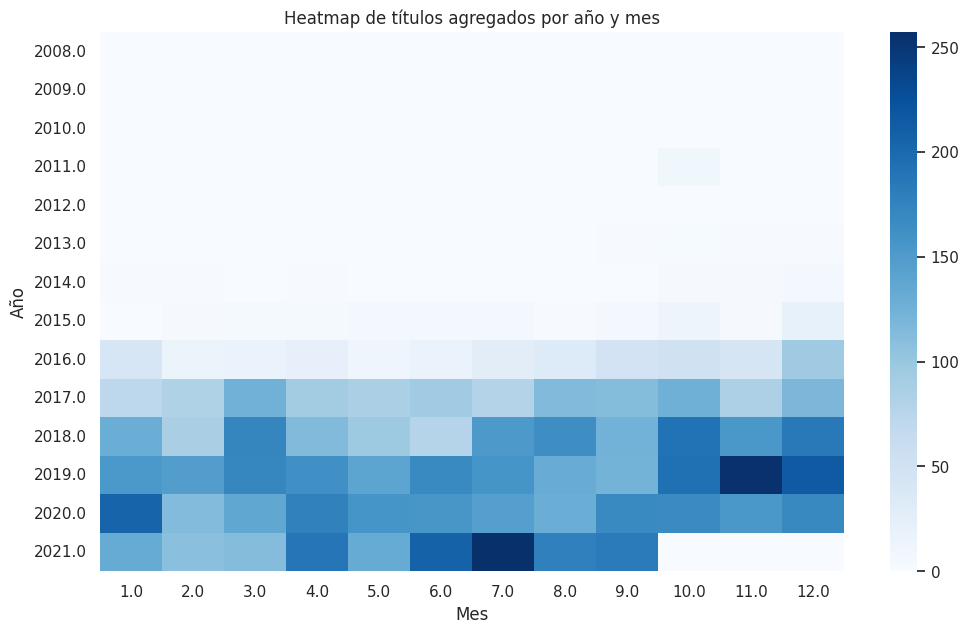

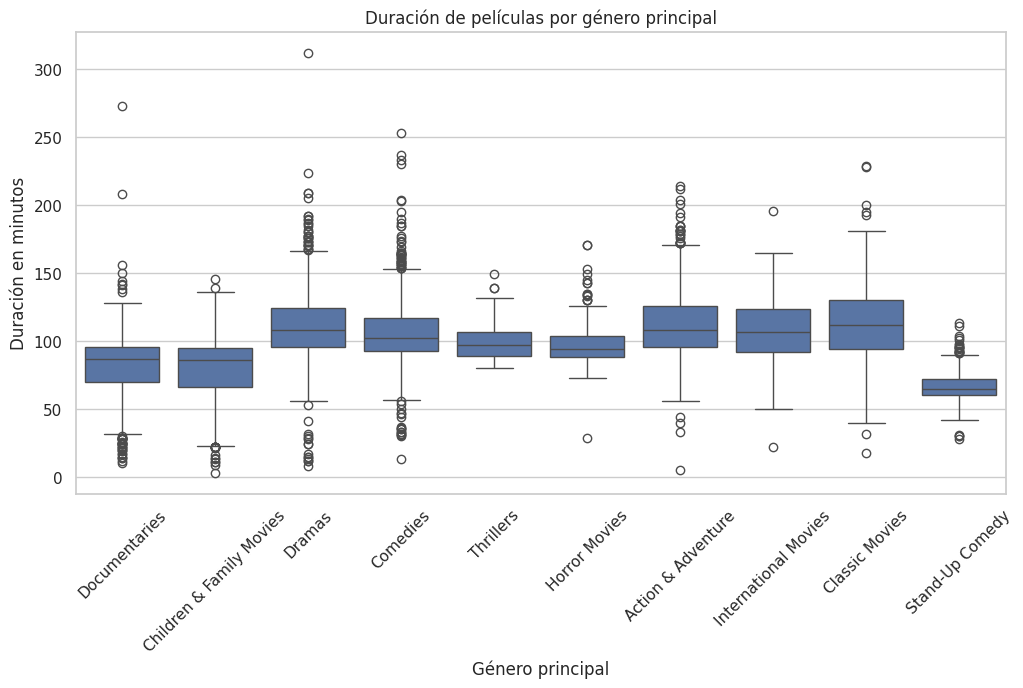

Resumen de duración por género principal:


,count,mean,std,min,25%,50%,75%,max
main_genre,,,,,,,,
Classic Movies,80.0,114.825000,40.716300,18.0,94.0,112.0,130.25,229.0
Action & Adventure,859.0,113.515716,25.079838,5.0,96.0,108.0,126.00,214.0
Dramas,1600.0,111.377500,23.595719,8.0,96.0,108.0,124.00,312.0
International Movies,128.0,108.062500,25.264195,22.0,92.0,107.0,123.50,196.0
Comedies,1210.0,106.687603,23.086415,13.0,93.0,102.0,117.00,253.0
Thrillers,65.0,99.953846,15.385089,80.0,89.0,97.0,107.00,149.0
Horror Movies,275.0,98.174545,16.002466,29.0,88.0,94.0,103.50,171.0
Documentaries,829.0,82.149578,24.230262,10.0,70.0,87.0,96.00,273.0
Children & Family Movies,605.0,78.426446,26.092042,3.0,66.0,86.0,95.00,146.0


In [7]:
# Parte 2: Tendencias y evolución en el tiempo

# Convertir date_added a formato fecha
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), errors="coerce")

# Crear columnas auxiliares de año y mes de incorporación
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# 4. Número de títulos agregados por año
titles_by_year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=titles_by_year.index, y=titles_by_year.values, marker="o")
plt.title("Número de títulos agregados a Netflix por año")
plt.xlabel("Año agregado al catálogo")
plt.ylabel("Cantidad de títulos")
plt.xticks(rotation=45)
plt.show()

print("Títulos agregados por año:")
display(titles_by_year)

# 5. Heatmap de títulos agregados por año y mes
heatmap_data = (
    df
    .dropna(subset=["year_added", "month_added"])
    .groupby(["year_added", "month_added"])
    .size()
    .reset_index(name="cantidad")
)

heatmap_pivot = heatmap_data.pivot(
    index="year_added",
    columns="month_added",
    values="cantidad"
).fillna(0)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_pivot, cmap="Blues", annot=False, fmt=".0f")
plt.title("Heatmap de títulos agregados por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# 6. Duración de películas por género principal

# Extraer duración numérica
df["duration_number"] = df["duration"].str.extract(r"(\d+)").astype(float)

# Filtrar solo películas
movies = df[df["type"] == "Movie"].copy()

# Para películas, duration_number corresponde a minutos
movies["duration_minutes"] = movies["duration_number"]

# Extraer género principal
movies["main_genre"] = movies["listed_in"].str.split(",").str[0].str.strip()

# Seleccionar los 10 géneros principales para que el gráfico no quede saturado
top_movie_genres = movies["main_genre"].value_counts().head(10).index

movies_top_genres = movies[movies["main_genre"].isin(top_movie_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=movies_top_genres, x="main_genre", y="duration_minutes")
plt.title("Duración de películas por género principal")
plt.xlabel("Género principal")
plt.ylabel("Duración en minutos")
plt.xticks(rotation=45)
plt.show()

print("Resumen de duración por género principal:")
display(
    movies_top_genres
    .groupby("main_genre")["duration_minutes"]
    .describe()
    .sort_values("mean", ascending=False)
)

El análisis de títulos agregados por año muestra que Netflix incorporó muy pocos contenidos entre 2008 y 2014, con cifras inferiores a 25 títulos por año. A partir de 2015 comienza un aumento importante, pasando de **82 títulos en 2015** a **429 en 2016**. Luego el crecimiento se acelera fuertemente, alcanzando **1188 títulos en 2017**, **1649 en 2018** y un máximo de **2016 títulos en 2019**.

El año **2019** aparece como el período con mayor incorporación de contenido al catálogo. Posteriormente, se observa una leve caída en **2020**, con **1879 títulos**, y una disminución mayor en **2021**, con **1498 títulos**. Esto puede estar relacionado con una estabilización del catálogo, cambios en la estrategia de incorporación de contenidos o efectos externos sobre la producción audiovisual.

El heatmap por año y mes permite observar la distribución temporal de los estrenos agregados. Los años con mayor intensidad visual corresponden principalmente a 2018, 2019, 2020 y 2021, lo que confirma que la mayor parte del crecimiento del catálogo se concentra en los años recientes. Este tipo de gráfico también permite identificar meses con mayor actividad de incorporación, aunque la tendencia más clara está dada por el crecimiento anual.

En cuanto a la duración de películas por género principal, se observan diferencias relevantes. Los géneros con mayor duración promedio son **Classic Movies**, con aproximadamente **114,8 minutos**, **Action & Adventure**, con **113,5 minutos**, y **Dramas**, con **111,4 minutos**. En cambio, géneros como **Stand-Up Comedy** presentan una duración promedio menor, cercana a **66,9 minutos**. Esto sugiere que los géneros narrativos tradicionales suelen tener películas más largas, mientras que formatos como comedia de stand-up tienden a ser más breves.



## 🔥 Parte 3: Comparaciones y relaciones

7. **Top 10 países con más producciones**

   * Usa un gráfico de barras para mostrar los países más frecuentes en la columna `country`.
   * Pregunta guía: ¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?

8. **Películas vs Series según género**

   * Realiza un gráfico de barras apiladas para mostrar la cantidad de títulos por género, separando `Movie` y `TV Show`.
   * Pregunta guía: ¿Existen géneros más asociados a películas o a series?

9. **Relación entre duración y año de lanzamiento**

   * Haz un gráfico de dispersión (scatterplot) con `release_year` en el eje X y `duration` (en minutos) en el eje Y.
   * Pregunta guía: ¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?



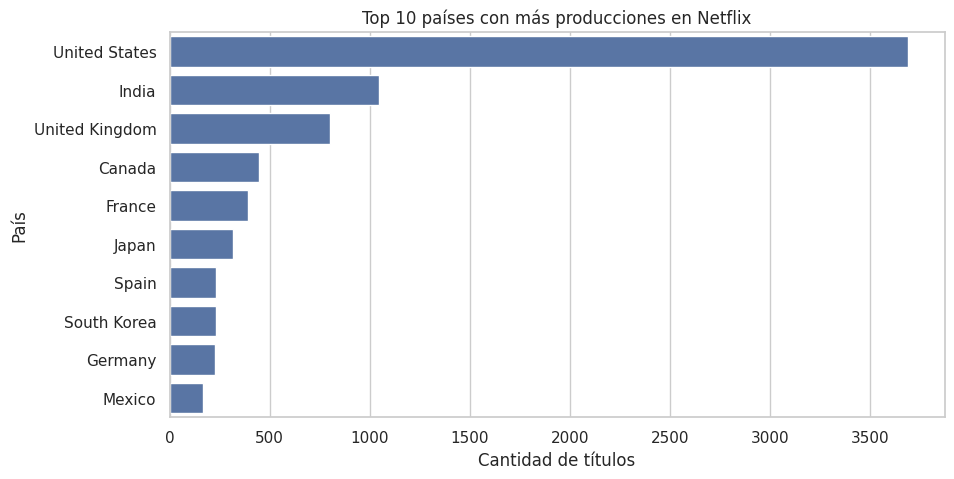

Top 10 países con más producciones:


,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


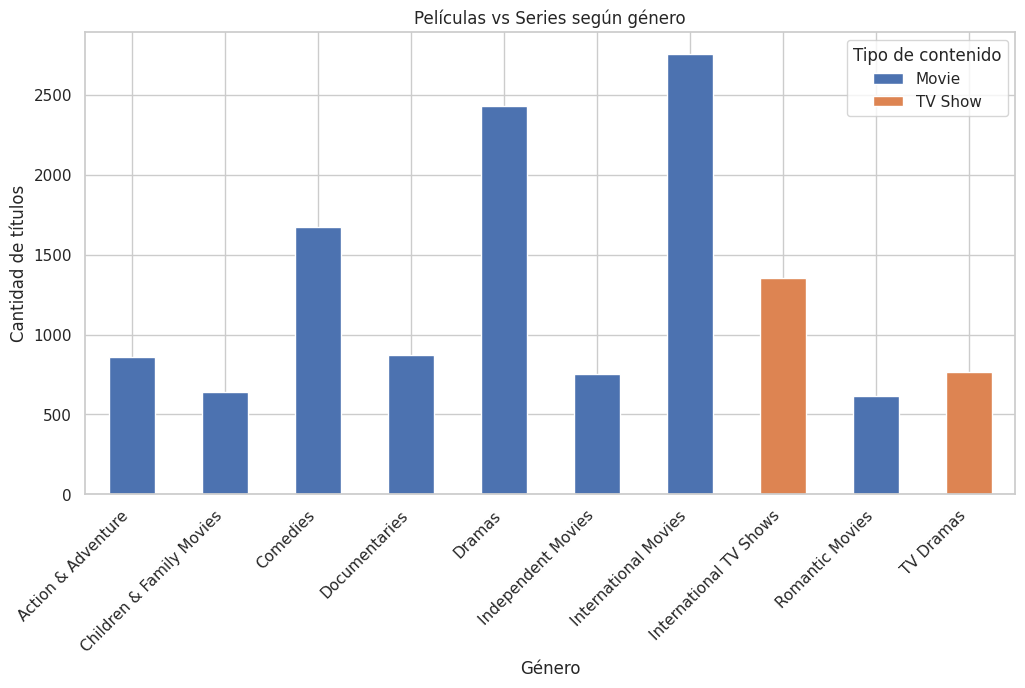

Tabla de géneros por tipo de contenido:


type,Movie,TV Show
genre,,
Action & Adventure,859.0,0.0
Children & Family Movies,641.0,0.0
Comedies,1674.0,0.0
Documentaries,869.0,0.0
Dramas,2427.0,0.0
Independent Movies,756.0,0.0
International Movies,2752.0,0.0
International TV Shows,0.0,1351.0
Romantic Movies,616.0,0.0


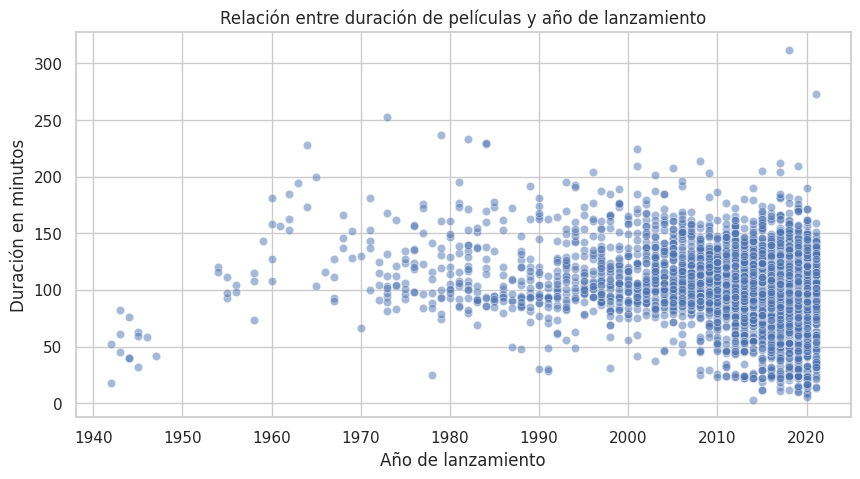

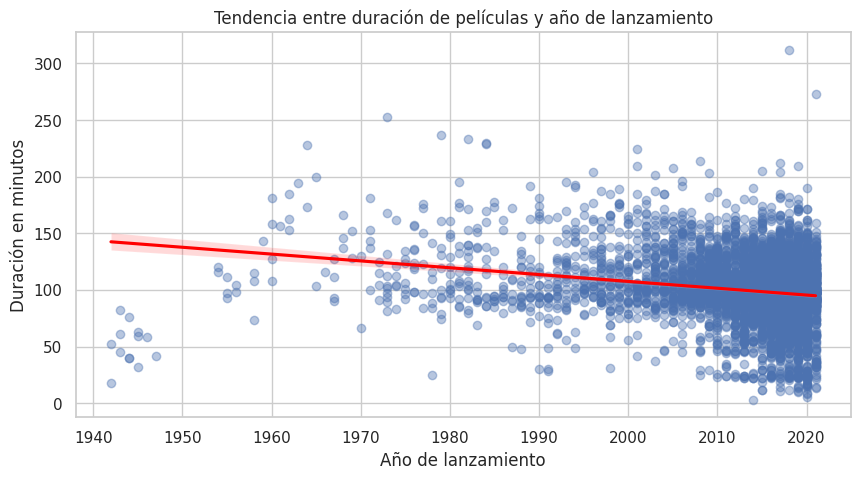

Resumen de duración de películas:


,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


Películas con mayor duración:


,title,release_year,duration,duration_minutes,listed_in
4253,Black Mirror: Bandersnatch,2018,312 min,312.0,"Dramas, International Movies, Sci-Fi & Fantasy"
717,Headspace: Unwind Your Mind,2021,273 min,273.0,Documentaries
2491,The School of Mischief,1973,253 min,253.0,"Comedies, Dramas, International Movies"
2487,No Longer kids,1979,237 min,237.0,"Comedies, Dramas, International Movies"
2484,Lock Your Girls In,1982,233 min,233.0,"Comedies, International Movies, Romantic Movies"
2488,Raya and Sakina,1984,230 min,230.0,"Comedies, Dramas, International Movies"
166,Once Upon a Time in America,1984,229 min,229.0,"Classic Movies, Dramas"
7932,Sangam,1964,228 min,228.0,"Classic Movies, Dramas, International Movies"
1019,Lagaan,2001,224 min,224.0,"Dramas, International Movies, Music & Musicals"
4573,Jodhaa Akbar,2008,214 min,214.0,"Action & Adventure, Dramas, International Movies"


In [8]:
# Parte 3: Comparaciones y relaciones

# 7. Top 10 países con más producciones

# Separar países cuando hay más de uno en la columna country
df_countries = (
    df
    .dropna(subset=["country"])
    .assign(country=df["country"].str.split(", "))
    .explode("country")
)

df_countries["country"] = df_countries["country"].str.strip()

top_10_countries = df_countries["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index)
plt.title("Top 10 países con más producciones en Netflix")
plt.xlabel("Cantidad de títulos")
plt.ylabel("País")
plt.show()

print("Top 10 países con más producciones:")
display(top_10_countries)

# 8. Películas vs Series según género

# Separar géneros de listed_in
df_genres = (
    df
    .dropna(subset=["listed_in"])
    .assign(genre=df["listed_in"].str.split(", "))
    .explode("genre")
)

df_genres["genre"] = df_genres["genre"].str.strip()

# Seleccionar los 10 géneros más frecuentes
top_10_genres = df_genres["genre"].value_counts().head(10).index

genre_type_table = (
    df_genres[df_genres["genre"].isin(top_10_genres)]
    .groupby(["genre", "type"])
    .size()
    .reset_index(name="cantidad")
)

genre_type_pivot = genre_type_table.pivot(
    index="genre",
    columns="type",
    values="cantidad"
).fillna(0)

genre_type_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Películas vs Series según género")
plt.xlabel("Género")
plt.ylabel("Cantidad de títulos")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tipo de contenido")
plt.show()

print("Tabla de géneros por tipo de contenido:")
display(genre_type_pivot)

# 9. Relación entre duración y año de lanzamiento

# Usar solo películas porque la duración está en minutos
movies_scatter = movies.dropna(subset=["release_year", "duration_minutes"]).copy()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=movies_scatter,
    x="release_year",
    y="duration_minutes",
    alpha=0.5
)
plt.title("Relación entre duración de películas y año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Duración en minutos")
plt.show()

# Agregar línea de tendencia
plt.figure(figsize=(10, 5))
sns.regplot(
    data=movies_scatter,
    x="release_year",
    y="duration_minutes",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.title("Tendencia entre duración de películas y año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Duración en minutos")
plt.show()

print("Resumen de duración de películas:")
display(movies_scatter["duration_minutes"].describe())

print("Películas con mayor duración:")
display(
    movies_scatter[["title", "release_year", "duration", "duration_minutes", "listed_in"]]
    .sort_values("duration_minutes", ascending=False)
    .head(10)
)

El ranking de países con más producciones muestra que **United States** domina ampliamente el catálogo, con **3689 títulos**, seguido por **India** con **1046** y **United Kingdom** con **804**. Luego aparecen Canadá, Francia, Japón, España, Corea del Sur, Alemania y México. Esta distribución es esperable, ya que Estados Unidos es uno de los principales productores audiovisuales a nivel mundial y Netflix tiene una fuerte base de contenido estadounidense.

India también destaca de manera importante, lo que refleja el peso de la industria cinematográfica india y la estrategia de Netflix de incorporar contenido internacional. La presencia de países como Japón, Corea del Sur, España y México evidencia que el catálogo no se limita al mercado anglosajón, sino que incluye una oferta internacional relevante.

En la comparación entre películas y series por género, se observa que varios géneros del top 10 están asociados exclusivamente a películas, como **International Movies**, **Dramas**, **Comedies**, **Documentaries**, **Action & Adventure** y **Children & Family Movies**. Por otro lado, géneros como **International TV Shows** y **TV Dramas** están asociados a series. Esto indica que la clasificación de géneros en el dataset diferencia bastante entre categorías propias de películas y categorías propias de televisión.

La relación entre duración y año de lanzamiento muestra que la mayoría de las películas se concentra entre los **80 y 120 minutos**, con una duración promedio de aproximadamente **99,6 minutos** y una mediana de **98 minutos**. También existen valores extremos, como **Black Mirror: Bandersnatch**, con **312 minutos**, y **Headspace: Unwind Your Mind**, con **273 minutos**. Estos casos pueden deberse a formatos especiales o registros particulares dentro del catálogo.

En general, no se observa una relación lineal fuerte entre el año de lanzamiento y la duración de las películas. Las películas recientes y antiguas presentan duraciones variadas, aunque la mayoría se mantiene dentro de rangos habituales para largometrajes.

## ⭐ Desafío Final

* Encuentra las combinaciones más frecuentes de **género + rating** y represéntalas en un **heatmap o gráfico de burbujas**.
* Pregunta guía: ¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?

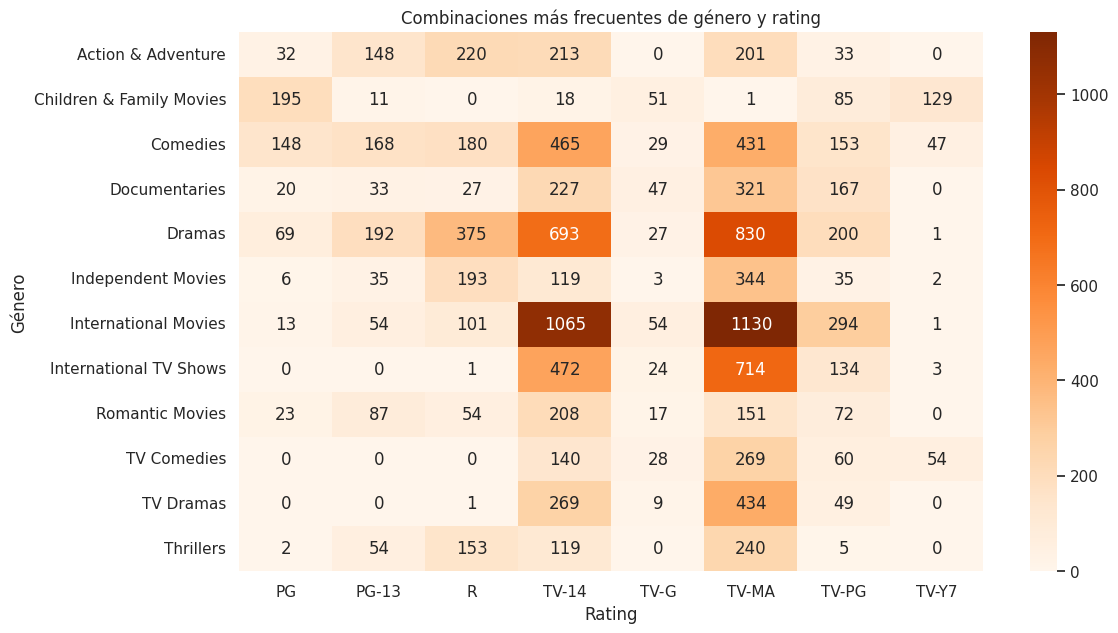

Tabla de combinaciones género + rating:


rating,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y7
genre,,,,,,,,
Action & Adventure,32.0,148.0,220.0,213.0,0.0,201.0,33.0,0.0
Children & Family Movies,195.0,11.0,0.0,18.0,51.0,1.0,85.0,129.0
Comedies,148.0,168.0,180.0,465.0,29.0,431.0,153.0,47.0
Documentaries,20.0,33.0,27.0,227.0,47.0,321.0,167.0,0.0
Dramas,69.0,192.0,375.0,693.0,27.0,830.0,200.0,1.0
Independent Movies,6.0,35.0,193.0,119.0,3.0,344.0,35.0,2.0
International Movies,13.0,54.0,101.0,1065.0,54.0,1130.0,294.0,1.0
International TV Shows,0.0,0.0,1.0,472.0,24.0,714.0,134.0,3.0
Romantic Movies,23.0,87.0,54.0,208.0,17.0,151.0,72.0,0.0


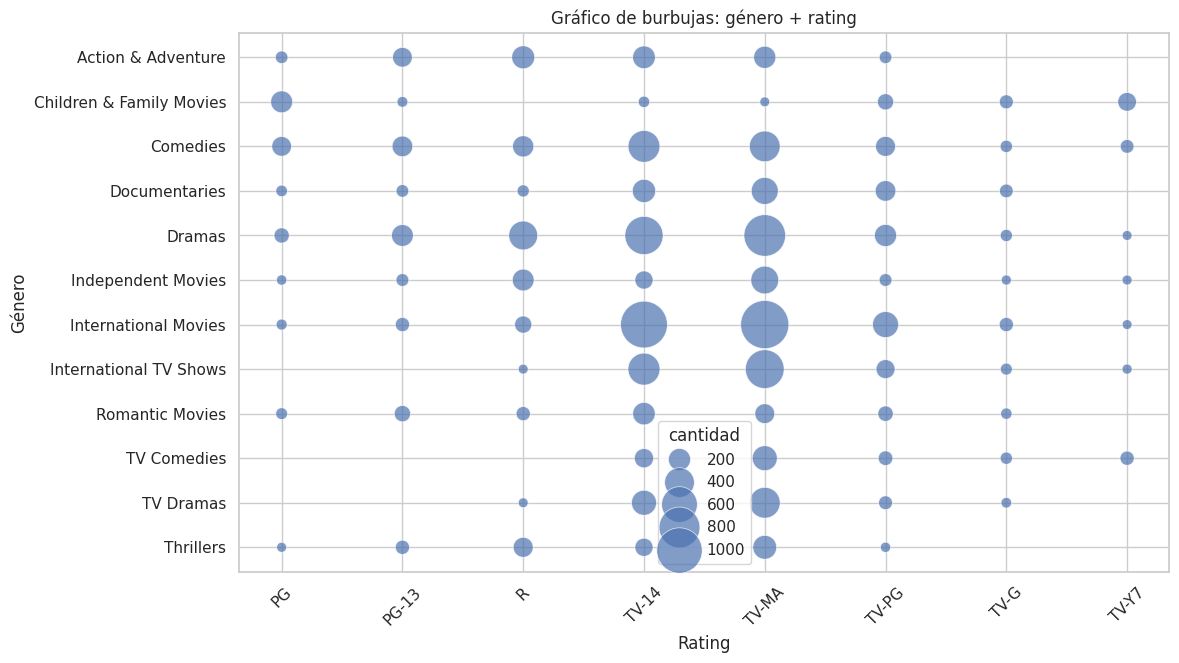

Top 15 combinaciones más frecuentes de género y rating:


,genre,rating,cantidad
140,International Movies,TV-MA,1130
138,International Movies,TV-14,1065
103,Dramas,TV-MA,830
149,International TV Shows,TV-MA,714
101,Dramas,TV-14,693
147,International TV Shows,TV-14,472
60,Comedies,TV-14,465
270,TV Dramas,TV-MA,434
62,Comedies,TV-MA,431
100,Dramas,R,375


In [9]:
# Desafío final: combinaciones más frecuentes de género + rating

# Asegurar que exista df_genres
df_genres = (
    df
    .dropna(subset=["listed_in", "rating"])
    .assign(genre=df["listed_in"].str.split(", "))
    .explode("genre")
)

df_genres["genre"] = df_genres["genre"].str.strip()

# Crear tabla de frecuencia género + rating
genre_rating_table = (
    df_genres
    .groupby(["genre", "rating"])
    .size()
    .reset_index(name="cantidad")
)

# Seleccionar géneros y ratings más frecuentes para que el heatmap sea legible
top_genres = df_genres["genre"].value_counts().head(12).index
top_ratings = df_genres["rating"].value_counts().head(8).index

genre_rating_filtered = genre_rating_table[
    (genre_rating_table["genre"].isin(top_genres)) &
    (genre_rating_table["rating"].isin(top_ratings))
]

genre_rating_pivot = genre_rating_filtered.pivot(
    index="genre",
    columns="rating",
    values="cantidad"
).fillna(0)

# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(genre_rating_pivot, cmap="Oranges", annot=True, fmt=".0f")
plt.title("Combinaciones más frecuentes de género y rating")
plt.xlabel("Rating")
plt.ylabel("Género")
plt.show()

print("Tabla de combinaciones género + rating:")
display(genre_rating_pivot)

# Gráfico de burbujas alternativo
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=genre_rating_filtered,
    x="rating",
    y="genre",
    size="cantidad",
    sizes=(50, 1200),
    alpha=0.7,
    legend=True
)
plt.title("Gráfico de burbujas: género + rating")
plt.xlabel("Rating")
plt.ylabel("Género")
plt.xticks(rotation=45)
plt.show()

print("Top 15 combinaciones más frecuentes de género y rating:")
display(
    genre_rating_table
    .sort_values("cantidad", ascending=False)
    .head(15)
)

El análisis de combinaciones entre género y clasificación etaria muestra que las categorías más frecuentes se concentran principalmente en contenido internacional, dramas, comedias y series internacionales. La combinación más repetida es **International Movies con TV-MA**, con **1130 títulos**, seguida por **International Movies con TV-14**, con **1065 títulos**. Esto indica que el contenido internacional tiene una presencia muy fuerte en el catálogo y está orientado principalmente a audiencias adultas y adolescentes.

También destacan los **Dramas**, especialmente con clasificación **TV-MA** con **830 títulos** y **TV-14** con **693 títulos**. Esto muestra que los dramas son uno de los géneros más relevantes dentro del catálogo y que suelen estar dirigidos a públicos de mayor edad. De forma similar, **International TV Shows** aparece con **714 títulos TV-MA** y **472 TV-14**, reforzando la importancia del contenido internacional seriado.

Las **Comedies** también tienen una presencia importante, con **465 títulos TV-14** y **431 títulos TV-MA**. Esto sugiere que, aunque la comedia puede estar asociada a públicos amplios, en este catálogo una parte importante está clasificada para adolescentes y adultos.

En cuanto al público familiar o infantil, destacan géneros como **Children & Family Movies**, donde aparecen valores relevantes en clasificaciones **PG**, **TV-Y7**, **TV-PG** y **TV-G**. Esto muestra que Netflix también cuenta con contenido orientado a familias y niños, aunque en menor proporción que el contenido adulto o adolescente.

En síntesis, el catálogo analizado está fuertemente concentrado en contenido internacional y géneros de alta demanda como dramas y comedias, principalmente con clasificaciones **TV-MA** y **TV-14**. Esto sugiere una estrategia de catálogo orientada a audiencias adultas y adolescentes, aunque también existe una oferta familiar e infantil relevante.

El laboratorio permitió analizar visualmente el catálogo de Netflix mediante gráficos de barras, histogramas, series temporales, heatmaps, boxplots, gráficos apilados y gráficos de dispersión. A partir de estos análisis, se observa que el catálogo está compuesto principalmente por películas, con una presencia menor pero significativa de series.

Los resultados muestran que Netflix concentra gran parte de su contenido en títulos recientes, especialmente lanzados desde la década de 2010. Además, la incorporación de títulos al catálogo creció con fuerza a partir de 2016 y alcanzó su punto más alto en 2019. Esto refleja una etapa de fuerte expansión del catálogo en los años previos a 2020.

Desde el punto de vista geográfico, Estados Unidos domina ampliamente la producción de contenidos presentes en Netflix, seguido por India y Reino Unido. Sin embargo, también existe una presencia importante de contenido internacional, lo que se confirma en el análisis de géneros y ratings.

En términos de clasificación etaria, predominan los contenidos **TV-MA** y **TV-14**, lo que indica una orientación importante hacia audiencias adultas y adolescentes. Los géneros más frecuentes, como International Movies, Dramas, Comedies e International TV Shows, refuerzan esta tendencia. Aun así, el catálogo también incluye contenido familiar e infantil, aunque en menor proporción.

En conclusión, el catálogo de Netflix analizado muestra una estrategia amplia, internacional y fuertemente orientada a contenido reciente, con predominio de películas y clasificaciones para público adulto o adolescente.